### imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure
import pandas as pd
from config import get_control_file

### array to df

In [ ]:
# load npy file for participant
participant = 1
trial_number = 5
file_path = get_control_file(participant)
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

def participant_pupil_stats(data):
    pupil_chunks = []
    n_trials = data.shape[2]
    for idx in range(n_trials):
        trial_pupil = data[2, :, idx].astype(float)
        p_mu = np.nanmean(trial_pupil)
        p_sigma = np.nanstd(trial_pupil)
        if np.isfinite(p_mu) and np.isfinite(p_sigma) and p_sigma > 0:
            trial_pupil_z = (trial_pupil - p_mu) / p_sigma
        else:
            trial_pupil_z = np.full_like(trial_pupil, np.nan, dtype=float)
        mask = trial_pupil_z < -2.0
        mask = ndimage.binary_dilation(mask, iterations=15)
        trial_pupil = trial_pupil.copy()
        trial_pupil[mask] = np.nan
        trial_pupil = trial_pupil[np.isfinite(trial_pupil)]
        if trial_pupil.size > 0:
            pupil_chunks.append(trial_pupil)

    if pupil_chunks:
        pooled = np.concatenate(pupil_chunks)
        return float(np.nanmean(pooled)), float(np.nanstd(pooled))
    return np.nan, np.nan

pupil_mu, pupil_sigma = participant_pupil_stats(data)
if np.isfinite(pupil_mu) and np.isfinite(pupil_sigma) and pupil_sigma > 0:
    df['pupil_z'] = (df['pupil'] - pupil_mu) / pupil_sigma
else:
    df['pupil_z'] = np.nan




### pupil dilation

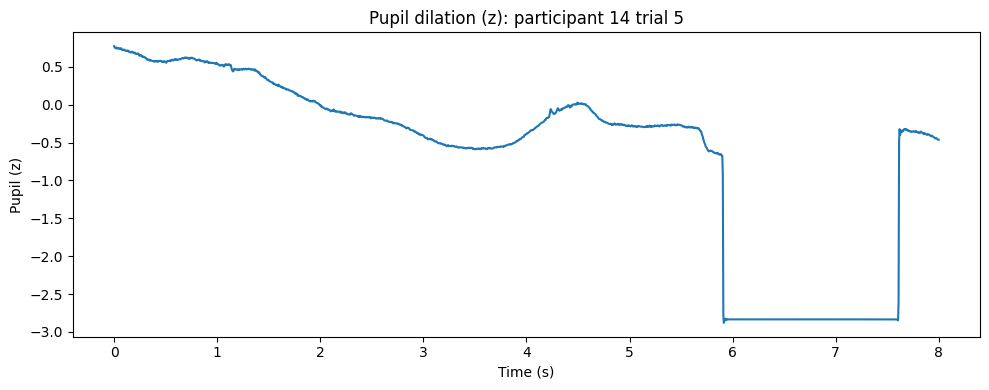

In [3]:
fs = 200  # sampling frequency Hz
samples = data.shape[1]

time = np.arange(samples) / fs

plt.figure(figsize=(10,4))
plt.plot(time, df['pupil_z'])
plt.title(f'Pupil dilation (z): participant {participant} trial {trial_number}')
plt.xlabel('Time (s)')
plt.ylabel('Pupil (z)')
plt.tight_layout()
plt.show()



### blink check

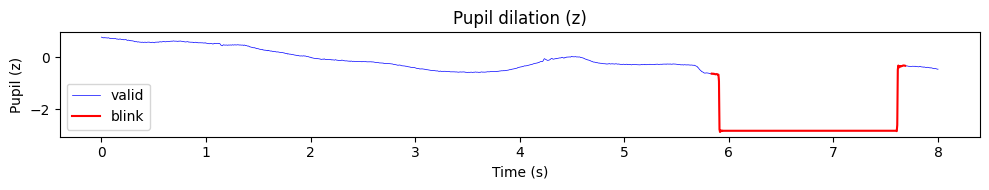

In [4]:
blink_mask = df['pupil_z'] < -2.0 # True = blink, False = valid (z threshold)
blink_mask = ndimage.binary_dilation(blink_mask, iterations=15)
time = np.arange(samples) / fs

plt.figure(figsize=(10,2))

blink_p = np.where(blink_mask, df['pupil_z'], np.nan)  # non-blink points become gaps
plt.plot(time, df['pupil_z'], color='blue', label='valid', lw = 0.5)
plt.plot(time, blink_p, color='red', label='blink')

plt.title('Pupil dilation (z)')
plt.xlabel('Time (s)')
plt.ylabel('Pupil (z)')
plt.legend()
plt.tight_layout()
plt.show()




### visualising the trial

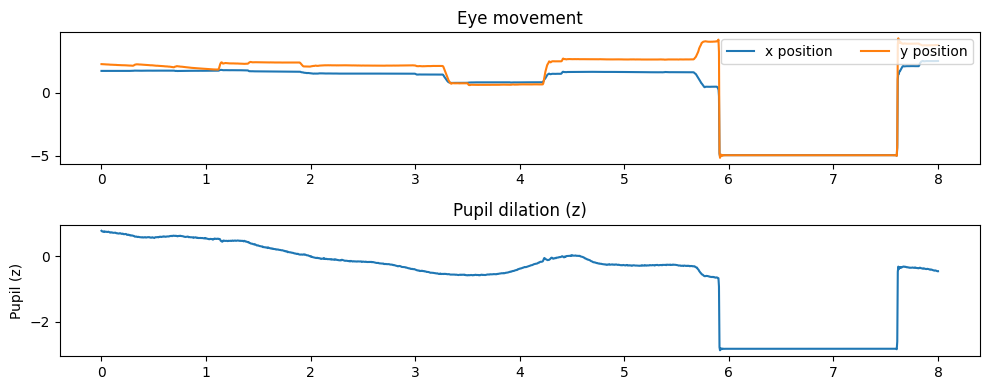

In [5]:
plt.figure(figsize = (10,4))
plt.subplot(2,1,1)
plt.plot(time, df['x'], label = 'x position')
plt.subplot(2,1,1)
plt.plot(time, df['y'], label = 'y position')
plt.legend(loc = 'upper right', ncol = 2)
plt.title('Eye movement')

plt.subplot(2,1,2)
plt.title('Pupil dilation (z)')
plt.plot(time, df['pupil_z'])
plt.ylabel('Pupil (z)')
plt.tight_layout()

plt.show()



### ignoring blinks

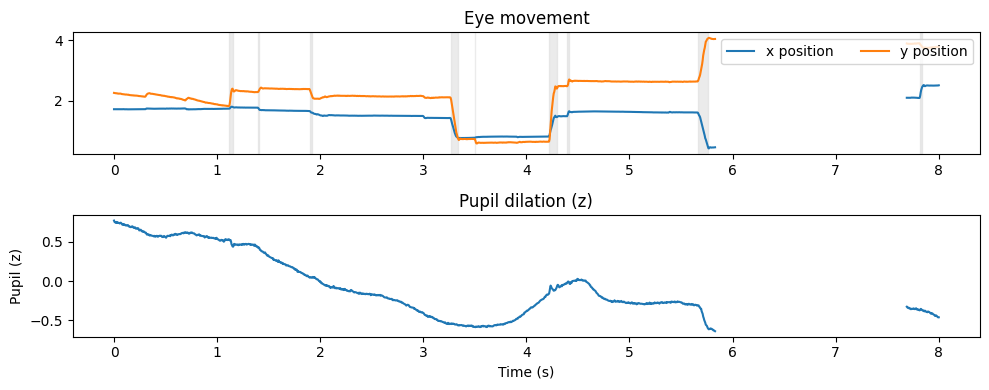

In [6]:
df_clean = df.copy()
df_clean.loc[blink_mask, :] = np.nan

# detect saccade intervals on blink-cleaned eye position
merging_ms = 10
thr_z = 1
iters = max(1, int((merging_ms / 1000.0) * fs))

x = df_clean['x']
y = df_clean['y']
speed = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
mu = np.nanmean(speed)
sigma = np.nanstd(speed)
if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0:
    speed_z = (speed - mu) / sigma
else:
    speed_z = np.full_like(speed, np.nan, dtype=float)
raw = speed_z > thr_z
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
labelled, _ = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)
time_speed = np.arange(len(speed)) / fs

plt.figure(figsize = (10,4))
ax1 = plt.subplot(2,1,1)

# shade detected saccades in the background (panel C, first graph)
for r in regions:
    if r is None:
        continue
    start = r[0].start
    stop = r[0].stop
    ax1.axvspan(time_speed[start], time_speed[max(start, stop - 1)], color='0.85', alpha=0.5, zorder=0)

ax1.plot(time, df_clean['x'], label = 'x position')
ax1.plot(time, df_clean['y'], label = 'y position')
ax1.legend(loc = 'upper right', ncol = 2)
ax1.set_title('Eye movement')

ax2 = plt.subplot(2,1,2)
ax2.set_title('Pupil dilation (z)')
ax2.plot(time, df_clean['pupil_z'])
ax2.set_ylabel('Pupil (z)')
ax2.set_xlabel('Time (s)')
plt.tight_layout()

plt.show()



### saccade info:

number of saccades = 9


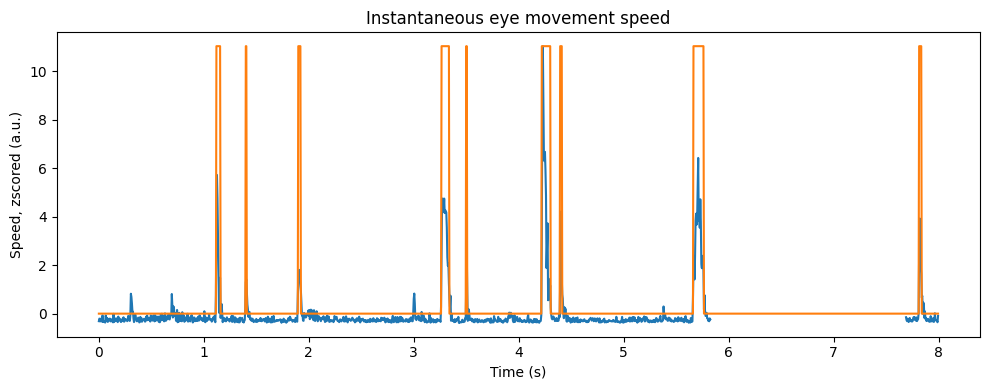

number of saccades = 9
   label  start_s  end_s  duration_ms  mean_speed  max_speed
0      1    1.120  1.155         40.0    2.728933   5.718411
1      2    1.400  1.405         10.0    1.353221   1.408499
2      3    1.900  1.920         25.0    1.516038   1.803821
3      4    3.265  3.335         75.0    3.557004   4.744778
4      5    3.500  3.505         10.0    1.826110   2.511176
5      6    4.220  4.300         85.0    4.441247  11.028784
6      7    4.395  4.410         20.0    2.379973   4.211528
7      8    5.665  5.760        100.0    3.261045   6.419370
8      9    7.815  7.835         25.0    2.608674   3.924643


In [7]:
samples = data.shape[1]
trials = data.shape[2]

merging_ms = 10
thr_z = 1

x = df_clean['x']
y = df_clean['y']
pupil_z = df_clean['pupil_z']

xdiff = np.diff(x) ** 2
ydiff = np.diff(y) ** 2
speed = np.sqrt(xdiff + ydiff)
mu = np.nanmean(speed)
sigma = np.nanstd(speed)
if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0:
    speed_z = (speed - mu) / sigma
else:
    speed_z = np.full_like(speed, np.nan, dtype=float)
time = np.arange(len(speed)) / fs  # seconds (fs = 200Hz)

plt.figure(figsize=(10,4))

plt.plot(time, speed_z)


plt.title('Instantaneous eye movement speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed, zscored (a.u.)')
plt.tight_layout()

# --- saccade statistics ---
iters = max(1, int((merging_ms / 1000.0) * fs))   # samples to merge at fs Hz

raw = speed_z > thr_z
# print('raw > thr_z:', int(raw.sum()))
# print('iters (samples merged):', iters)
# merge short gaps between supra-threshold samples
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
# optional gentle cleanup to remove isolated single-sample noise (commented by default)
# saccades = ndimage.binary_opening(saccades)

labelled, n = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)

movement = saccades
print(f'number of saccades = {n}')

plt.plot(time, movement*np.nanmax(speed_z))

plt.show()

labels = measure.label(movement.astype(np.uint8), connectivity=1)
props = measure.regionprops_table(
    labels[:, None],                 # make it 2-D for skimage
    intensity_image=speed_z[:, None],  # to get mean/max speed per saccade
    properties=('label', 'area', 'bbox', 'mean_intensity', 'max_intensity')
)

stats_df = pd.DataFrame(props).rename(
    columns = {
        'area': 'n_samples',
        'bbox-0': 'start_idx',
        'bbox-2': 'end_idx_exclusive',
        'mean_intensity': 'mean_speed',
        'max_intensity': 'max_speed'
    }
)

stats_df['end_idx'] = stats_df['end_idx_exclusive'] - 1
stats_df['start_s'] = stats_df['start_idx'] / fs
stats_df['end_s'] = stats_df['end_idx'] / fs
stats_df['duration_ms'] = (stats_df['n_samples'] / fs) * 1000

# throw away durations <10ms

print(f"number of saccades = {len(stats_df)}")
print(stats_df[['label','start_s','end_s','duration_ms','mean_speed','max_speed']])



### exclude noisy trials

some trials (eg. participant 10 trial 23) are super noisy - can just be thrown out entirely on basis of variance?

In [8]:
# load npy file for participant
participant = 5
trial_number = 36
file_path = f'/Users/anji/Desktop/lab project/EyeData/controls/ctrl_{participant}.npy'
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

pupil_mu, pupil_sigma = participant_pupil_stats(data)
if np.isfinite(pupil_mu) and np.isfinite(pupil_sigma) and pupil_sigma > 0:
    df['pupil_z'] = (df['pupil'] - pupil_mu) / pupil_sigma
else:
    df['pupil_z'] = np.nan

pupvar = np.nanvar(df['pupil_z'])
xvar = np.nanvar(df['x'])
yvar = np.nanvar(df['y'])
print('variance:')
print(' pupil_z =', pupvar)
print(' x =', xvar)
print(' y =', yvar)



variance:
 pupil_z = 0.5509532090298134
 x = 8.292741141595373e-11
 y = 6.194608408863724e-11
